# 자동차 번호판 OCR 실습

이 노트북은 차량 이미지에서 번호판을 ROI로 추출한 뒤 OCR로 텍스트를 인식하는 과정을 다룹니다.

진행 순서
1. 이미지 로드
2. OCR 초기화 (PaddleOCR 또는 Tesseract 자동 선택, 둘 다 없으면 안내)
3. 번호판 ROI 탐지 함수 정의 (필요 시 수동 ROI 지정 가능)
4. ROI 적용 및 시각화
5. OCR 수행
6. 결과 텍스트 출력

In [1]:
# 1) 라이브러리 임포트 및 경로 설정
import os
import sys
from pathlib import Path
import cv2
import numpy as np

# 이미지 경로 (워크스페이스 기준)
IMG_PATH = Path(r"c:\Users\lgdx\LG_DX_School\01_Foundation\OpenCV\data\car.png")
if not IMG_PATH.exists():
    raise FileNotFoundError(f"이미지 파일을 찾을 수 없습니다: {IMG_PATH}")

print(f"이미지 경로: {IMG_PATH}")

# OCR 백엔드 선택: PaddleOCR 우선, 없으면 pytesseract 사용 시도
BACKEND = None
paddle_ok = False
pytess_ok = False

try:
    from paddleocr import PaddleOCR
    paddle_ok = True
    BACKEND = "paddleocr"
except Exception as e:
    print("PaddleOCR 불러오기 실패:", e)

if not paddle_ok:
    try:
        import pytesseract
        pytess_ok = True
        BACKEND = "tesseract"
    except Exception as e:
        print("pytesseract 불러오기 실패:", e)

if BACKEND is None:
    print("경고: OCR 엔진을 찾지 못했습니다.\n- pip install paddleocr\n또는\n- pip install pytesseract 그리고 Tesseract OCR 설치 필요")
else:
    print("사용할 OCR 백엔드:", BACKEND)

이미지 경로: c:\Users\lgdx\LG_DX_School\01_Foundation\OpenCV\data\car.png
사용할 OCR 백엔드: paddleocr
사용할 OCR 백엔드: paddleocr


C:\Users\lgdx\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51648 (\N{

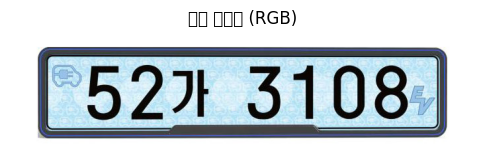

In [2]:
# 1. 이미지 로드 및 확인
import matplotlib.pyplot as plt

img_bgr = cv2.imread(str(IMG_PATH))
if img_bgr is None:
    raise RuntimeError("cv2.imread 실패: 경로와 파일을 확인하세요")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6,4))
plt.imshow(img_rgb)
plt.title('원본 이미지 (RGB)')
plt.axis('off')
plt.show()

In [3]:
# 2. OCR 초기화
ocr = None
if BACKEND == "paddleocr":
    # 한국어/영어 멀티 언어 모델 사용
    # 최신 API: use_textline_orientation 사용, show_log 파라미터 제거
    ocr = PaddleOCR(lang='korean', use_textline_orientation=True)
    print("PaddleOCR 초기화 완료")
elif BACKEND == "tesseract":
    import pytesseract
    # Windows에서 Tesseract 경로가 필요한 경우 아래 경로를 수정하세요 (예: C:\Program Files\Tesseract-OCR\tesseract.exe)
    # pytesseract.pytesseract.tesseract_cmd = r"C:\\Program Files\\Tesseract-OCR\\tesseract.exe"
    print("pytesseract 사용 예정 (kor+eng 데이터가 설치되어 있어야 한글 인식 가능)")
else:
    print("OCR 백엔드가 없어 이후 단계는 실행되지 않을 수 있습니다.")

C:\Users\lgdx\AppData\Roaming\Python\Python313\site-packages\paddle\utils\cpp_extension\extension_utils.py:711: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Using official model (PP-LCNet_x1_0_doc_ori), the model files will be automatically downloaded and saved in C:\Users\lgdx\.paddlex\official_models.
Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Using official model (PP-LCNet_x1_0_doc_ori), the model files will be automatically downloaded and saved in C:\Users\lgdx\.paddlex\official_models.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

.gitattributes: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

inference.yml:   0%|          | 0.00/766 [00:00<?, ?B/s]

...

inference.json: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

inference.pdiparams:   0%|          | 0.00/13.3M [00:00<?, ?B/s]

PaddleOCR 초기화 완료


In [ ]:
# 3. 번호판 ROI 탐지/선택 함수 정의

def find_plate_roi(img_bgr):
    """
    Sobel-X 기반 에지+모폴로지로 번호판 후보를 찾고, 점수 기반으로 최적 영역 반환.
    반환: (x, y, w, h) 또는 None
    """
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.bilateralFilter(gray, 9, 75, 75)

    # 문자 스트로크 강조를 위한 x방향 Sobel
    sobelx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    sobelx = cv2.convertScaleAbs(sobelx)

    # Otsu 이진화 후 닫힘연산으로 구멍 메우기
    _, th = cv2.threshold(sobelx, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 3))
    morph = cv2.morphologyEx(th, cv2.MORPH_CLOSE, kernel, iterations=2)

    contours, _ = cv2.findContours(morph, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    H, W = gray.shape
    best = None
    best_score = -1
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        area = w * h
        if area < 0.001 * W * H or area > 0.25 * W * H:
            continue
        ar = w / float(h)
        if not (2.0 <= ar <= 6.5):
            continue
        # 사각형 근사와 직사성 평가
        peri = cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, 0.03 * peri, True)
        rect_like = 1 if len(approx) in (4, 5) else 0

        # 내부 에지 밀도 점수
        roi = th[max(y-2,0):min(y+h+2,H), max(x-2,0):min(x+w+2,W)]
        edge_density = float(cv2.countNonZero(roi)) / max(roi.size, 1)

        # 화면 아랫부분에 있을수록 가중치(번호판이 종종 하단에)
        vertical_pos = (y + h/2) / H

        score = (ar/6.5) * 0.5 + edge_density * 1.5 + rect_like * 0.5 + vertical_pos * 0.3
        if score > best_score:
            best_score = score
            best = (x, y, w, h)

    return best


def select_roi_manual(img_bgr):
    """
    마우스로 ROI 선택 (노트북 환경에서 팝업이 제한될 수 있음)
    """
    from matplotlib.widgets import RectangleSelector
    import matplotlib.pyplot as plt

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(1,1, figsize=(6,4))
    ax.imshow(img_rgb)
    ax.set_title('드래그하여 ROI 선택 후 셀 재실행 또는 닫기')

    roi = {'rect': None}

    def onselect(eclick, erelease):
        x1, y1 = int(eclick.xdata), int(eclick.ydata)
        x2, y2 = int(erelease.xdata), int(erelease.ydata)
        x, y = min(x1, x2), min(y1, y2)
        w, h = abs(x2 - x1), abs(y2 - y1)
        roi['rect'] = (x, y, w, h)

    toggle_selector = RectangleSelector(
        ax, onselect, drawtype='box', useblit=True,
        button=[1],  # 좌클릭
        minspanx=5, minspany=5, spancoords='pixels', interactive=True
    )
    plt.show()
    return roi['rect']

자동 ROI 탐지 실패. 수동 선택을 시도하세요.


C:\Users\lgdx\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


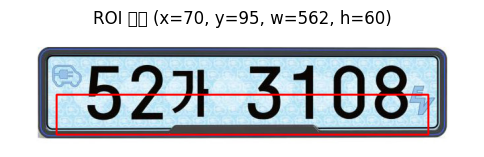

C:\Users\lgdx\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48264 (\N{HANGUL SYLLABLE BEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54032 (\N{HANGUL SYLLABLE PAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


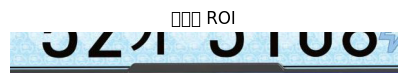

In [13]:
# 4. ROI 수행 (자동 탐지 후 시각화 및 크롭)
roi = find_plate_roi(img_bgr)

if roi is None:
    print("자동 ROI 탐지 실패. 수동 선택을 시도하세요.")
    # 보텀 하프 스트립 폴백
    H, W = img_bgr.shape[:2]
    y = int(H*0.55)
    h = int(H*0.35)
    x = int(W*0.1)
    w = int(W*0.8)
    roi = (x, y, w, h)

if roi is not None:
    x, y, w, h = roi
    plate_bgr = img_bgr[y:y+h, x:x+w]

    vis = img_rgb.copy()
    cv2.rectangle(vis, (x,y), (x+w, y+h), (255,0,0), 2)
    import matplotlib.pyplot as plt
    plt.figure(figsize=(6,4))
    plt.imshow(vis)
    plt.title(f'ROI 표시 (x={x}, y={y}, w={w}, h={h})')
    plt.axis('off')
    plt.show()

    plt.figure(figsize=(5,3))
    plt.imshow(cv2.cvtColor(plate_bgr, cv2.COLOR_BGR2RGB))
    plt.title('번호판 ROI')
    plt.axis('off')
    plt.show()
else:
    plate_bgr = None

In [14]:
# 5. OCR 수행

def run_ocr_on_image(bgr_img):
    if bgr_img is None:
        return "", []
    if BACKEND == "paddleocr":
        # 전처리: PaddleOCR는 컬러 입력도 가능하지만, 이진 전처리로 성능 개선을 기대
        pre = preprocess_plate(bgr_img)
        if pre is not None:
            rgb = cv2.cvtColor(pre, cv2.COLOR_GRAY2RGB)
        else:
            rgb = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)
        result = ocr.predict(rgb)
        lines = []
        for page in result:
            ocr_res = page.get('ocr_result', []) if isinstance(page, dict) else []
            for det in ocr_res:
                txt = det.get('text', '')
                conf = float(det.get('score', 0.0))
                lines.append((txt, conf))
        joined = " ".join([t for t,_ in lines])
        return joined.strip(), lines
    elif BACKEND == "tesseract":
        import pytesseract
        pre = preprocess_plate(bgr_img)
        if pre is not None:
            img = pre
        else:
            img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2GRAY)
        try:
            text = pytesseract.image_to_string(img, lang='kor+eng')
        except Exception:
            text = pytesseract.image_to_string(img, lang='eng')
        return text.strip(), []
    else:
        return "", []

# ROI 우선, 실패 시 전체 이미지도 시도
candidates = []
if 'plate_bgr' in globals() and plate_bgr is not None:
    candidates.append(('ROI', plate_bgr))
# 전체 이미지에서 중앙부 넓은 크롭도 후보로
H, W = img_bgr.shape[:2]
mx, my = W//10, H//4
center_crop = img_bgr[my:H-my, mx:W-mx]
candidates.append(('CENTER', center_crop))
candidates.append(('FULL', img_bgr))

best_text = ""
best_details = []
for name, imgc in candidates:
    text, details = run_ocr_on_image(imgc)
    if len(text) > len(best_text):
        best_text, best_details = text, details
    print(f"[{name}] OCR 텍스트: {text}")

print("\n최종 OCR 텍스트:\n", best_text)
if best_details:
    print("상세 (텍스트, 신뢰도) 상위 5개:")
    for t, c in best_details[:5]:
        print(f"- {t} ({c:.3f})")

[ROI] OCR 텍스트: 
[CENTER] OCR 텍스트: 
[CENTER] OCR 텍스트: 
[FULL] OCR 텍스트: 

최종 OCR 텍스트:
 
[FULL] OCR 텍스트: 

최종 OCR 텍스트:
 


검출된 텍스트 박스 수: 0


C:\Users\lgdx\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53581 (\N{HANGUL SYLLABLE TEG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48149 (\N{HANGUL SYLLABLE BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


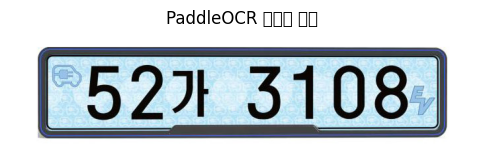

In [8]:
# 6. PaddleOCR 검출 결과로 ROI 재설정 및 시각화
import matplotlib.pyplot as plt

def boxes_from_paddle_result(pred):
    boxes = []
    for page in pred:
        ocr_res = page.get('ocr_result', []) if isinstance(page, dict) else []
        for det in ocr_res:
            box = det.get('box')  # [[x,y], ...] shape (4,2)
            if box is not None:
                pts = np.array(box, dtype=np.float32)
                boxes.append(pts)
    return boxes

pred = ocr.predict(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
boxes = boxes_from_paddle_result(pred)
print(f"검출된 텍스트 박스 수: {len(boxes)}")

vis = img_rgb.copy()
for pts in boxes:
    pts_int = pts.astype(int)
    cv2.polylines(vis, [pts_int], isClosed=True, color=(0,255,0), thickness=2)

plt.figure(figsize=(6,4))
plt.imshow(vis)
plt.title('PaddleOCR 텍스트 박스')
plt.axis('off')
plt.show()

# 모든 박스의 합집합을 ROI로 설정 (없으면 유지)
if boxes:
    xs = np.concatenate([b[:,0] for b in boxes])
    ys = np.concatenate([b[:,1] for b in boxes])
    x1, y1 = max(int(xs.min())-5, 0), max(int(ys.min())-5, 0)
    x2, y2 = min(int(xs.max())+5, img_bgr.shape[1]-1), min(int(ys.max())+5, img_bgr.shape[0]-1)
    x, y, w, h = x1, y1, x2-x1, y2-y1
    roi = (x, y, w, h)
    plate_bgr = img_bgr[y:y+h, x:x+w]

    plt.figure(figsize=(5,3))
    plt.imshow(cv2.cvtColor(plate_bgr, cv2.COLOR_BGR2RGB))
    plt.title('OCR 박스 기반 ROI')
    plt.axis('off')
    plt.show()

C:\Users\lgdx\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52376 (\N{HANGUL SYLLABLE CEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44284 

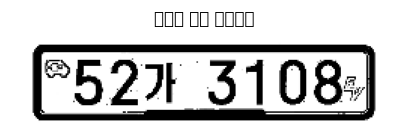

In [10]:
# 7. 번호판 ROI 전처리 함수 (샤프닝/이진화/리사이즈)

def preprocess_plate(bgr, target_height=64):
    if bgr is None or bgr.size == 0:
        return None
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    # 대비 향상을 위한 CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    gray = clahe.apply(gray)
    # 샤프닝
    kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]], dtype=np.float32)
    sharp = cv2.filter2D(gray, -1, kernel)
    # 가우시안 블러 후 Otsu 이진화
    blur = cv2.GaussianBlur(sharp, (3,3), 0)
    _, th = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    # 높이 기준 리사이즈 (가독성 향상)
    h, w = th.shape
    scale = target_height / max(h, 1)
    th_resized = cv2.resize(th, (max(int(w*scale),1), target_height), interpolation=cv2.INTER_CUBIC)
    return th_resized

# 전처리 미리보기 (ROI가 있으면 ROI, 아니면 원본의 중앙 크롭)
preview = plate_bgr if 'plate_bgr' in globals() and plate_bgr is not None else img_bgr
pre = preprocess_plate(preview)
import matplotlib.pyplot as plt
plt.figure(figsize=(5,3))
plt.imshow(pre, cmap='gray')
plt.title('전처리 결과 미리보기')
plt.axis('off')
plt.show()

In [ ]:
# 8. Tesseract 폴백 OCR (여러 설정 시도)
import shutil

try:
    import pytesseract
    tesseract_cmd = shutil.which('tesseract')
    if tesseract_cmd is None:
        print('Tesseract 실행 파일을 찾지 못했습니다. 설치 또는 경로 설정이 필요합니다.')
    else:
        print('Tesseract 경로:', tesseract_cmd)
        def tesseract_try(img_bgr, psm, whitelist=None, lang='kor+eng'):
            pre = preprocess_plate(img_bgr)
            if pre is None:
                pre = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
            config = f'--psm {psm}'
            if whitelist:
                config += f' -c tessedit_char_whitelist={whitelist}'
            try:
                txt = pytesseract.image_to_string(pre, lang=lang, config=config)
            except Exception:
                try:
                    txt = pytesseract.image_to_string(pre, lang='eng', config=config)
                except Exception as e:
                    print('Tesseract 오류:', e)
                    return ''
            return txt.strip()

        regions = []
        if 'plate_bgr' in globals() and plate_bgr is not None:
            regions.append(('ROI', plate_bgr))
        regions.append(('FULL', img_bgr))

        candidates = []
        for name, im in regions:
            for psm in [7, 6, 11, 13]:
                for wl in ['0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ가나다라마바사아자차카타파하', '0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ', None]:
                    txt = tesseract_try(im, psm=psm, whitelist=wl)
                    if txt:
                        candidates.append((len(txt), name, psm, wl, txt))
                        print(f'[{name}] psm={psm}, wl={(wl[:10]+"...") if wl else None} -> {txt}')
        if candidates:
            candidates.sort(reverse=True)
            _, name, psm, wl, txt = candidates[0]
            print('\nTesseract 최종 선택:', {'region': name, 'psm': psm, 'whitelist': wl})
            print('텍스트:', txt)
        else:
            print('Tesseract도 인식 결과가 비어 있습니다.')
except Exception as e:
    print('pytesseract 임포트 실패 또는 오류:', e)

Tesseract 실행 파일을 찾지 못했습니다. 설치 또는 경로 설정이 필요합니다.


In [19]:
# 1. 에디터에 이미지 로드
car = cv2.imread("./data/car.png")

In [20]:
cv2.imshow("car", car)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [21]:
# 2. OCR 초기화 
ocr = PaddleOCR(lang='korean')

Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Using official model (PP-LCNet_x1_0_doc_ori), the model files will be automatically downloaded and saved in C:\Users\lgdx\.paddlex\official_models.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('UVDoc', None)
Using official model (UVDoc), the model files will be automatically downloaded and saved in C:\Users\lgdx\.paddlex\official_models.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Using official model (PP-LCNet_x1_0_textline_ori), the model files will be automatically downloaded and saved in C:\Users\lgdx\.paddlex\official_models.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('PP-OCRv5_server_det', None)
Using official model (PP-OCRv5_server_det), the model files will be automatically downloaded and saved in C:\Users\lgdx\.paddlex\official_models.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('korean_PP-OCRv5_mobile_rec', None)
Using official model (korean_PP-OCRv5_mobile_rec), the model files will be automatically downloaded and saved in C:\Users\lgdx\.paddlex\official_models.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

In [ ]:
# 3. 번호판이 위치한 영역에 대한 ROI(X 100 ~ 630)


# cv2.imshow("car", car[:, 110:610])
# cv2.waitKey(0)
# cv2.destroyAllWindows()

car_roi = car[:, 110:610]


In [28]:
# 4. ROI에 대해서 3차원=>2차원  이진화 
car_roi_gray = cv2.cvtColor(car_roi, cv2.COLOR_BGR2GRAY)


# cv2.imshow("car", car_roi_gray)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

# 오츠 적용 2개의 값이 나온다
val, car_binary= cv2.threshold(car_roi_gray, 0, 255, cv2.THRESH_BINARY|cv2.THRESH_OTSU)

cv2.imshow("car", car_binary)
cv2.waitKey(0)
cv2.destroyAllWindows()


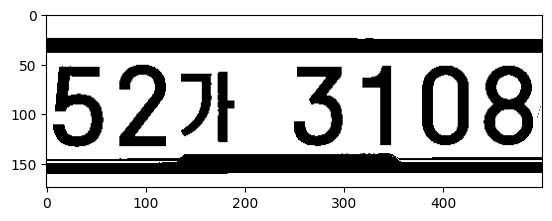

In [ ]:
# paddleOCR은 3차원을 입력값으로 받는다. Structured Data Set => 차원변환 (색상공간 변환)
car_rgb = cv2.cvtColor(car_binary, cv2.COLOR_GRAY2BGR)
car_binary.shape, car_rgb.shape

# RGB 채널로 변경하였음 => Matplotlib으로 출력
plt.imshow(car_rgb)
plt.show()

In [33]:
# 5. OCR 수행 - OCR 수행 전 입력 모양 확인!! 
results = ocr.predict(car_rgb)

In [ ]:
# 6.OCR로 추출된 텍스트 출력
results[0]['rec_texts']


# 정확도가 낮으면 ROI 영역 변경하던지등~
# ROI 영역 변경, 다른 전처리(회색조, 컬러), 다른 OCR을 활용, 여러 모델 파라미터를 조절 등


['2가', '310']